<a href="https://colab.research.google.com/github/KazterING/abp7/blob/main/ABP7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================================
# Proyecto Módulo 7 - ABP
# Segmentador Inteligente de Clientes Minoristas
# ==========================================

"
Objetivo:
Desarrollar un sistema de segmentación de clientes utilizando técnicas de
aprendizaje no supervisado, aplicando reducción dimensional y algoritmos
de clusterización para identificar patrones de comportamiento.

Técnicas a utilizar:
- PCA
- t-SNE
- K-Means
- DBSCAN
- Agrupamiento Jerárquico
"

In [ ]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Reducción dimensional
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clusterización
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Métricas
from sklearn.metrics import silhouette_score

# Para dendrograma
from scipy.cluster.hierarchy import dendrogram, linkage

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style="whitegrid")

In [ ]:
# ==========================================
# Generación de dataset sintético de clientes
# ==========================================

np.random.seed(42)

n_clientes = 300

# Segmento 1: Jóvenes con alto gasto
edad_1 = np.random.normal(25, 4, 100)
ingreso_1 = np.random.normal(40, 10, 100)
gasto_1 = np.random.normal(80, 10, 100)

# Segmento 2: Adultos con ingreso alto pero gasto moderado
edad_2 = np.random.normal(45, 6, 100)
ingreso_2 = np.random.normal(90, 15, 100)
gasto_2 = np.random.normal(50, 10, 100)

# Segmento 3: Mayores con bajo gasto
edad_3 = np.random.normal(60, 5, 100)
ingreso_3 = np.random.normal(60, 10, 100)
gasto_3 = np.random.normal(30, 8, 100)

# Unir datos
edad = np.concatenate([edad_1, edad_2, edad_3])
ingreso = np.concatenate([ingreso_1, ingreso_2, ingreso_3])
gasto = np.concatenate([gasto_1, gasto_2, gasto_3])

# Género aleatorio
genero = np.random.choice(['Male', 'Female'], n_clientes)

# Crear DataFrame
df = pd.DataFrame({
    'Edad': edad,
    'Ingreso_Anual': ingreso,
    'Puntaje_Gasto': gasto,
    'Genero': genero
})

# Ajustar valores negativos si aparecen
df['Edad'] = df['Edad'].clip(lower=18)
df['Ingreso_Anual'] = df['Ingreso_Anual'].clip(lower=10)
df['Puntaje_Gasto'] = df['Puntaje_Gasto'].clip(lower=1, upper=100)

df.head()

,Edad,Ingreso_Anual,Puntaje_Gasto,Genero
0,26.986857,25.846293,83.577874,Male
1,24.446943,35.793547,85.607845,Female
2,27.590754,36.572855,90.830512,Female
3,31.092119,31.977227,90.538021,Female
4,24.063387,38.387143,66.223306,Female


In [ ]:
# ==========================================
# Exploración inicial
# ==========================================

# Dimensiones del dataset
print("Dimensiones:", df.shape)

# Tipos de datos
df.info()

# Estadísticas descriptivas
df.describe()

Dimensiones: (300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Edad           300 non-null    float64
 1   Ingreso_Anual  300 non-null    float64
 2   Puntaje_Gasto  300 non-null    float64
 3   Genero         300 non-null    object 
dtypes: float64(3), object(1)
memory usage: 9.5+ KB


,Edad,Ingreso_Anual,Puntaje_Gasto
count,300.000000,300.000000,300.000000
mean,43.468619,63.107124,53.689482
std,15.350274,23.481436,22.076535
min,18.000000,20.812288,17.874047
25%,26.865840,44.255267,35.158123
50%,45.300944,60.719919,49.418410
75%,57.306507,78.111302,73.403278
max,72.866799,136.183212,100.000000


In [ ]:
# ==========================================
# Valores nulos
# ==========================================

df.isnull().sum()

,0
Edad,0
Ingreso_Anual,0
Puntaje_Gasto,0
Genero,0


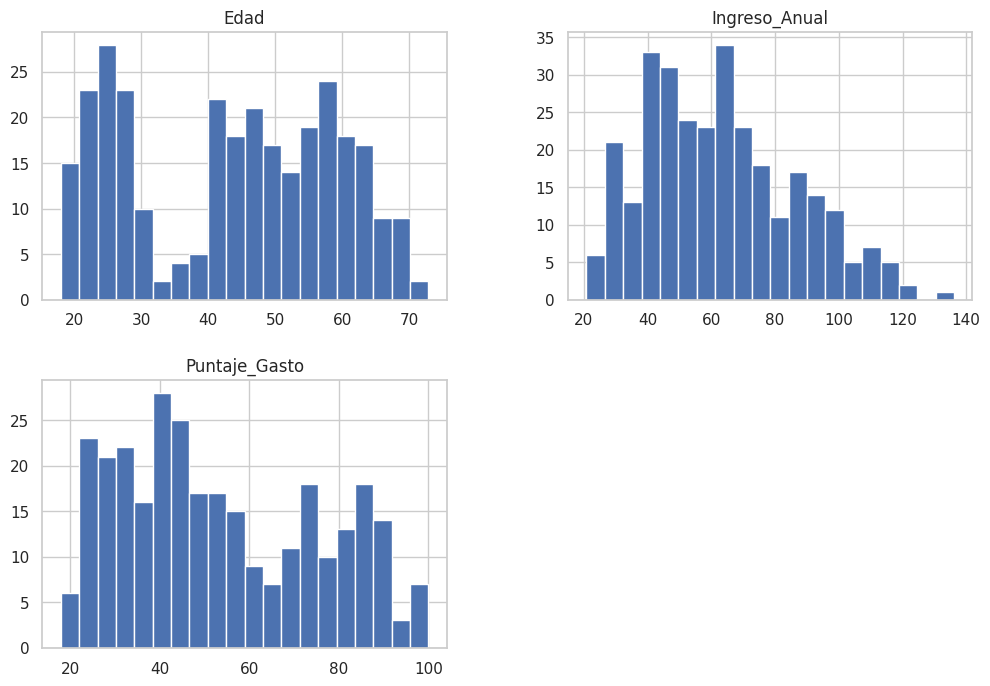

In [ ]:
# ==========================================
# Distribuciones
# ==========================================

df.hist(bins=20, figsize=(12,8))
plt.show()

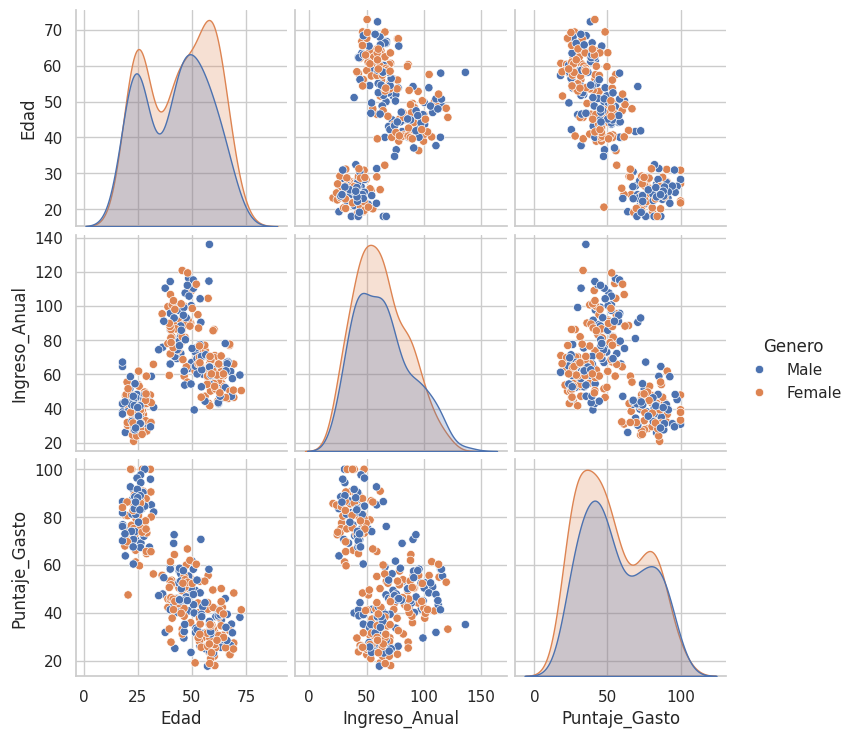

In [ ]:
# ==========================================
# Pairplot
# ==========================================

sns.pairplot(df, hue='Genero')
plt.show()

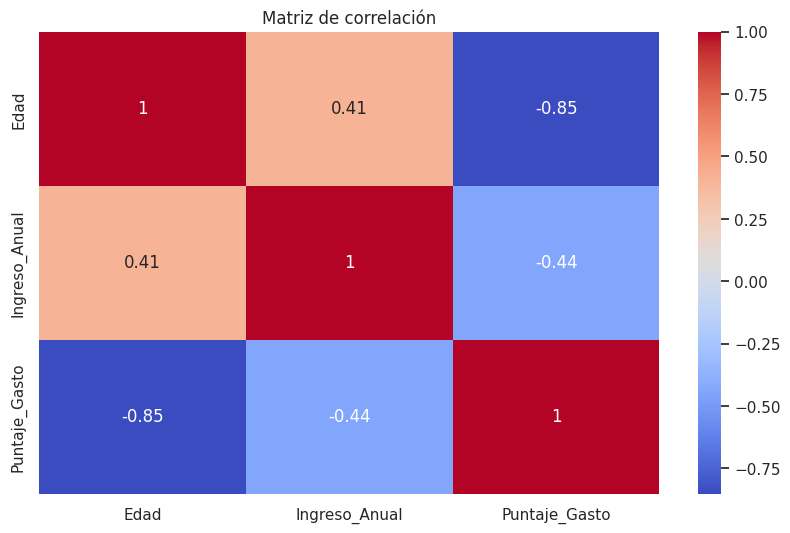

In [ ]:
# ==========================================
# Matriz de correlación
# ==========================================

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

In [ ]:
# ==========================================
# Encoding de variables categóricas
# ==========================================

le = LabelEncoder()
df['Genero'] = le.fit_transform(df['Genero'])

df.head()

,Edad,Ingreso_Anual,Puntaje_Gasto,Genero
0,26.986857,25.846293,83.577874,1
1,24.446943,35.793547,85.607845,0
2,27.590754,36.572855,90.830512,0
3,31.092119,31.977227,90.538021,0
4,24.063387,38.387143,66.223306,0


In [ ]:
# ==========================================
# Escalado de datos
# ==========================================

scaler = StandardScaler()

X = scaler.fit_transform(df)

# Convertimos a DataFrame para mantener claridad
X_scaled = pd.DataFrame(X, columns=df.columns)

X_scaled.head()

,Edad,Ingreso_Anual,Puntaje_Gasto,Genero
0,-1.075505,-1.589472,1.356115,1.098127
1,-1.241245,-1.165142,1.448221,-0.910642
2,-1.036098,-1.131899,1.685187,-0.910642
3,-0.807619,-1.327939,1.671916,-0.910642
4,-1.266274,-1.054505,0.568693,-0.910642


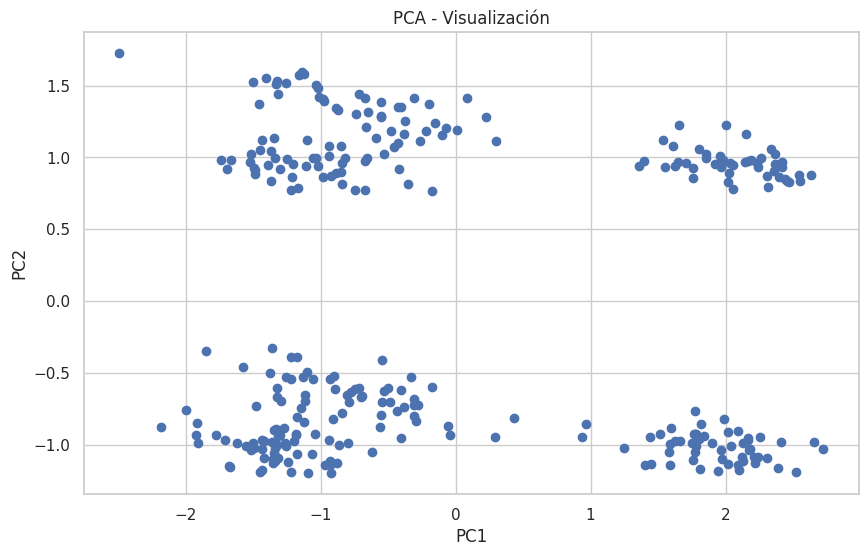

In [ ]:
# ==========================================
# PCA
# ==========================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# DataFrame para visualizar
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Visualización
plt.scatter(df_pca['PC1'], df_pca['PC2'])
plt.title("PCA - Visualización")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# ==========================================
# Varianza explicada
# ==========================================

print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

Varianza explicada por componente:
[0.54210637 0.25432471]


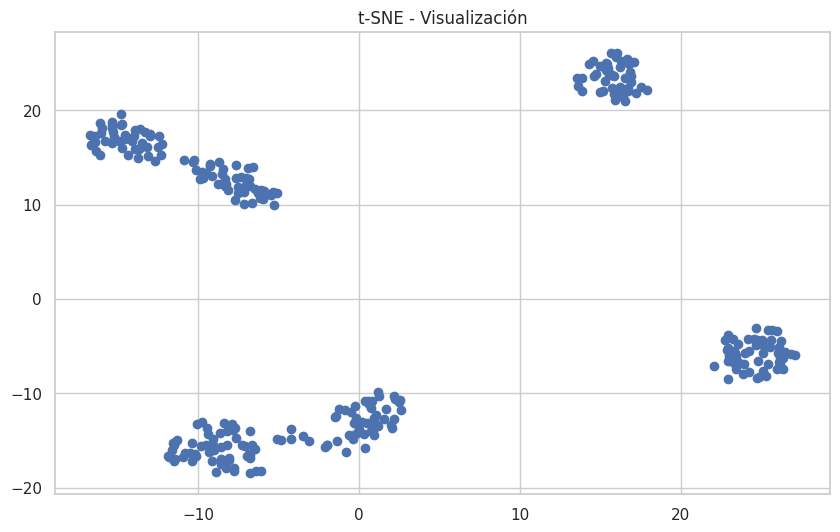

In [ ]:
# ==========================================
# t-SNE
# ==========================================

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])

plt.scatter(df_tsne['Dim1'], df_tsne['Dim2'])
plt.title("t-SNE - Visualización")
plt.show()

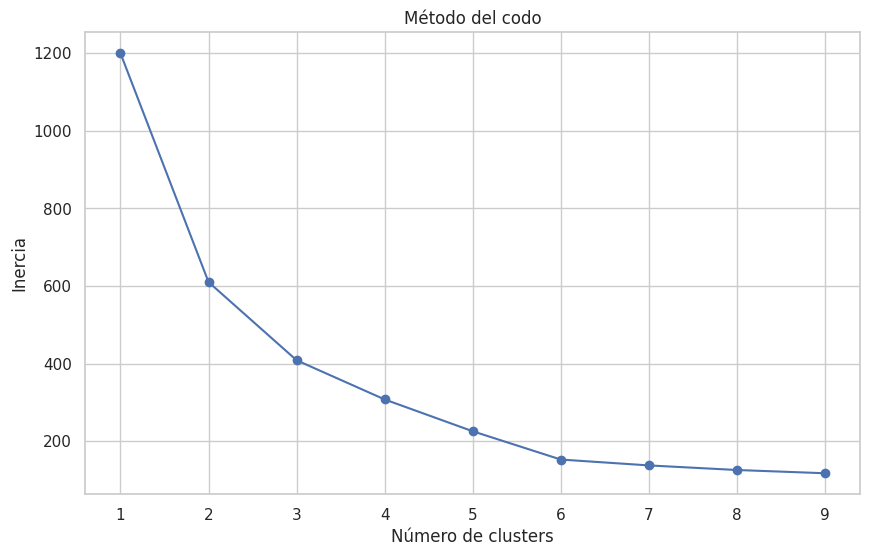

In [ ]:
# ==========================================
# Método del codo
# ==========================================

inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Gráfico
plt.plot(K, inertia, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

In [ ]:
# ==========================================
# K-Means
# ==========================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster_KMeans'] = clusters_kmeans

df.head()

,Edad,Ingreso_Anual,Puntaje_Gasto,Genero,Cluster_KMeans
0,26.986857,25.846293,83.577874,1,2
1,24.446943,35.793547,85.607845,0,2
2,27.590754,36.572855,90.830512,0,2
3,31.092119,31.977227,90.538021,0,2
4,24.063387,38.387143,66.223306,0,2


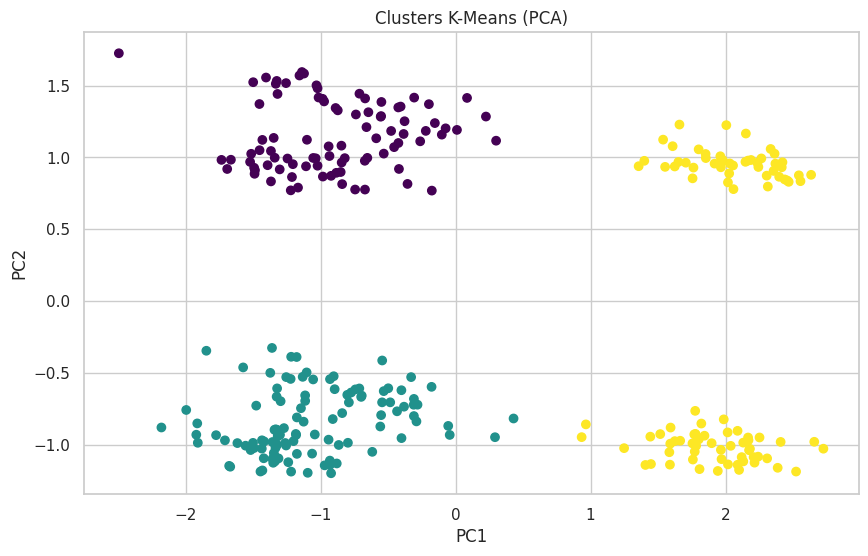

In [ ]:
# ==========================================
# Visualización K-Means
# ==========================================

plt.scatter(df_pca['PC1'], df_pca['PC2'], c=clusters_kmeans, cmap='viridis')
plt.title("Clusters K-Means (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# ==========================================
# Silhouette Score
# ==========================================

score_kmeans = silhouette_score(X_scaled, clusters_kmeans)
print("Silhouette Score (K-Means):", score_kmeans)

Silhouette Score (K-Means): 0.45619644144559096


In [ ]:
# ==========================================
# DBSCAN
# ==========================================

dbscan = DBSCAN(eps=1.2, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

df['Cluster_DBSCAN'] = clusters_dbscan

df.head()

,Edad,Ingreso_Anual,Puntaje_Gasto,Genero,Cluster_KMeans,Cluster_DBSCAN
0,26.986857,25.846293,83.577874,1,2,0
1,24.446943,35.793547,85.607845,0,2,1
2,27.590754,36.572855,90.830512,0,2,1
3,31.092119,31.977227,90.538021,0,2,1
4,24.063387,38.387143,66.223306,0,2,1


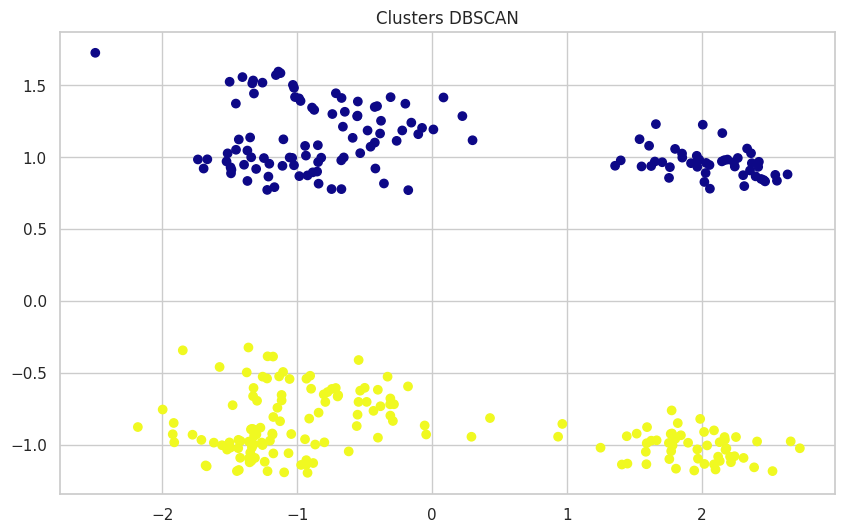

In [ ]:
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=clusters_dbscan, cmap='plasma')
plt.title("Clusters DBSCAN")
plt.show()

In [ ]:
# Filtrar ruido
mask = clusters_dbscan != -1

if len(set(clusters_dbscan[mask])) > 1:
    score_dbscan = silhouette_score(X_scaled[mask], clusters_dbscan[mask])
    print("Silhouette Score (DBSCAN):", score_dbscan)
else:
    print("DBSCAN no generó clusters suficientes")

Silhouette Score (DBSCAN): 0.29525925233823386


In [ ]:
# ==========================================
# Clustering jerárquico
# ==========================================

hierarchical = AgglomerativeClustering(n_clusters=3)
clusters_hier = hierarchical.fit_predict(X_scaled)

df['Cluster_Hierarchical'] = clusters_hier

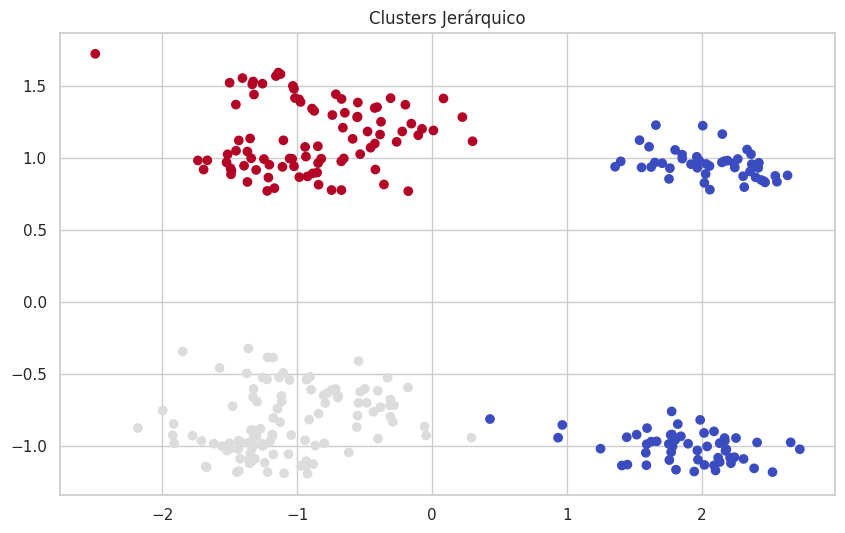

In [ ]:
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=clusters_hier, cmap='coolwarm')
plt.title("Clusters Jerárquico")
plt.show()

In [ ]:
score_hier = silhouette_score(X_scaled, clusters_hier)
print("Silhouette Score (Jerárquico):", score_hier)

Silhouette Score (Jerárquico): 0.45561072529987884


In [ ]:
# ==========================================
# Perfil de clusters K-Means
# ==========================================

df.groupby('Cluster_KMeans').mean()

,Edad,Ingreso_Anual,Puntaje_Gasto,Genero,Cluster_DBSCAN,Cluster_Hierarchical
Cluster_KMeans,,,,,,
0,52.078492,76.466048,41.736029,1.00,0.00,2.000000
1,53.524011,73.012202,39.217181,0.00,1.00,0.990991
2,24.644346,40.223046,80.392310,0.47,0.53,0.000000
